# Data parsing and exploration for learnedcache

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
import numpy as np
import keras
import csv
import glob
from pathlib import Path

2026-01-25 18:51:08.465083: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-25 18:51:08.465348: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-25 18:51:08.499517: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-25 18:51:09.510636: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

In [2]:
def parse_log_to_csv(input_filepath, output_filepath):
    """
    Parses a log file line-by-line and writes directly to a CSV 
    """
    with open(input_filepath, 'r') as infile:
        first_line = infile.readline()
        if not first_line:
            print("The file is empty.")
            return

        def parse_line(line):
            return dict(item.split('=') for item in line.strip().split() if '=' in item)

        initial_data = parse_line(first_line)
        fieldnames = list(initial_data.keys())

        with open(output_filepath, 'w', newline='') as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()
            
            writer.writerow(initial_data)

            for line in infile:
                if line.strip():
                    row_data = parse_line(line)
                    writer.writerow(row_data)

def transform_logs_to_csvs(input_pattern):
    """
    Parses multiple log files matching the input pattern and writes each to a corresponding CSV file.
    """
    filepaths = glob.glob(input_pattern)
    for filepath in filepaths:
        parse_log_to_csv(filepath, Path(filepath).with_suffix('.csv'))

In [3]:
def read_csvs_to_dataframe(file_pattern: str) -> pd.DataFrame:
    """
    Reads multiple CSV files and concatenates them into a single dataframe.
    Adds a trial_id column based on the sequence in which files are loaded.
    """
    filepaths = glob.glob(file_pattern)
    dataframes = []
    for trial_id, filepath in enumerate(filepaths):
        df = pd.read_csv(filepath)
        df['trial_id'] = trial_id
        dataframes.append(df)
    combined_df = pd.concat(dataframes, ignore_index=True)
    
    return combined_df


In [10]:
transform_logs_to_csvs('data/fileserver/*.log')

In [4]:
df = read_csvs_to_dataframe('data/fileserver/*access.csv')

In [12]:
df.head()

,t,d,i,o,s,z,f,trial_id
0,0,0:3,265289728,12582958,0,67641540608,1000,0
1,0,0:3,265289728,12582958,0,67641540608,1000,0
2,0,0:3,265289728,12582958,0,67641540608,1000,0
3,0,0:3,265289728,12621856,0,67641540608,1000,0
4,0,0:3,265289728,12582958,0,67641540608,1000,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21136516 entries, 0 to 21136515
Data columns (total 8 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   t         int64 
 1   d         object
 2   i         int64 
 3   o         int64 
 4   s         int64 
 5   z         int64 
 6   f         int64 
 7   trial_id  int64 
dtypes: int64(7), object(1)
memory usage: 1.3+ GB


In [14]:
pd.set_option('display.precision', 5)
df.describe()

,t,i,o,s,z,f,trial_id
count,2.11365e+07,2.11365e+07,2.11365e+07,2.11365e+07,2.11365e+07,2.11365e+07,2.11365e+07
mean,2.38889e+09,1.26616e+08,1.87051e+06,5.47916e-01,3.21737e+10,2.17830e+06,3.43676e+00
std,6.07509e+09,1.32076e+08,2.28498e+06,4.97699e-01,3.37802e+10,2.07882e+07,2.28168e+00
min,0.00000e+00,1.00000e+00,0.00000e+00,0.00000e+00,0.00000e+00,1.00000e+03,0.00000e+00
25%,2.29230e+04,9.21258e+05,2.00000e+01,0.00000e+00,1.56332e+05,1.03100e+03,1.00000e+00
50%,1.29360e+07,9.25723e+05,6.62000e+02,1.00000e+00,4.81240e+05,4.00200e+03,3.00000e+00
75%,1.45910e+09,2.65290e+08,3.67029e+06,1.00000e+00,6.76415e+10,1.50156e+05,5.00000e+00
max,7.84853e+10,2.65290e+08,1.59599e+07,1.00000e+00,6.76415e+10,4.16784e+08,7.00000e+00


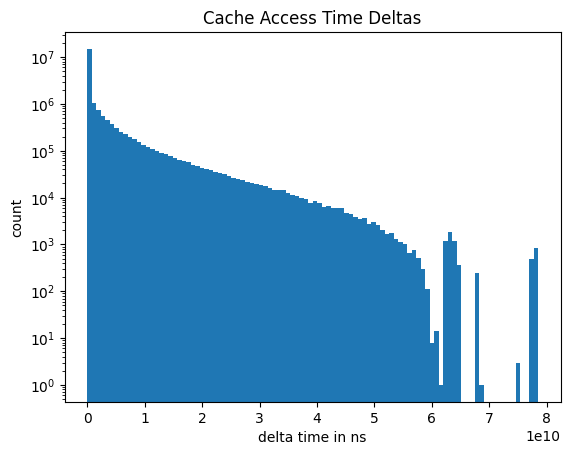

In [15]:
df['t'].plot(title='Cache Access Time Deltas', ylabel='count', xlabel="delta time in ns", kind='hist', bins=100)
plt.yscale('log')
plt.show()

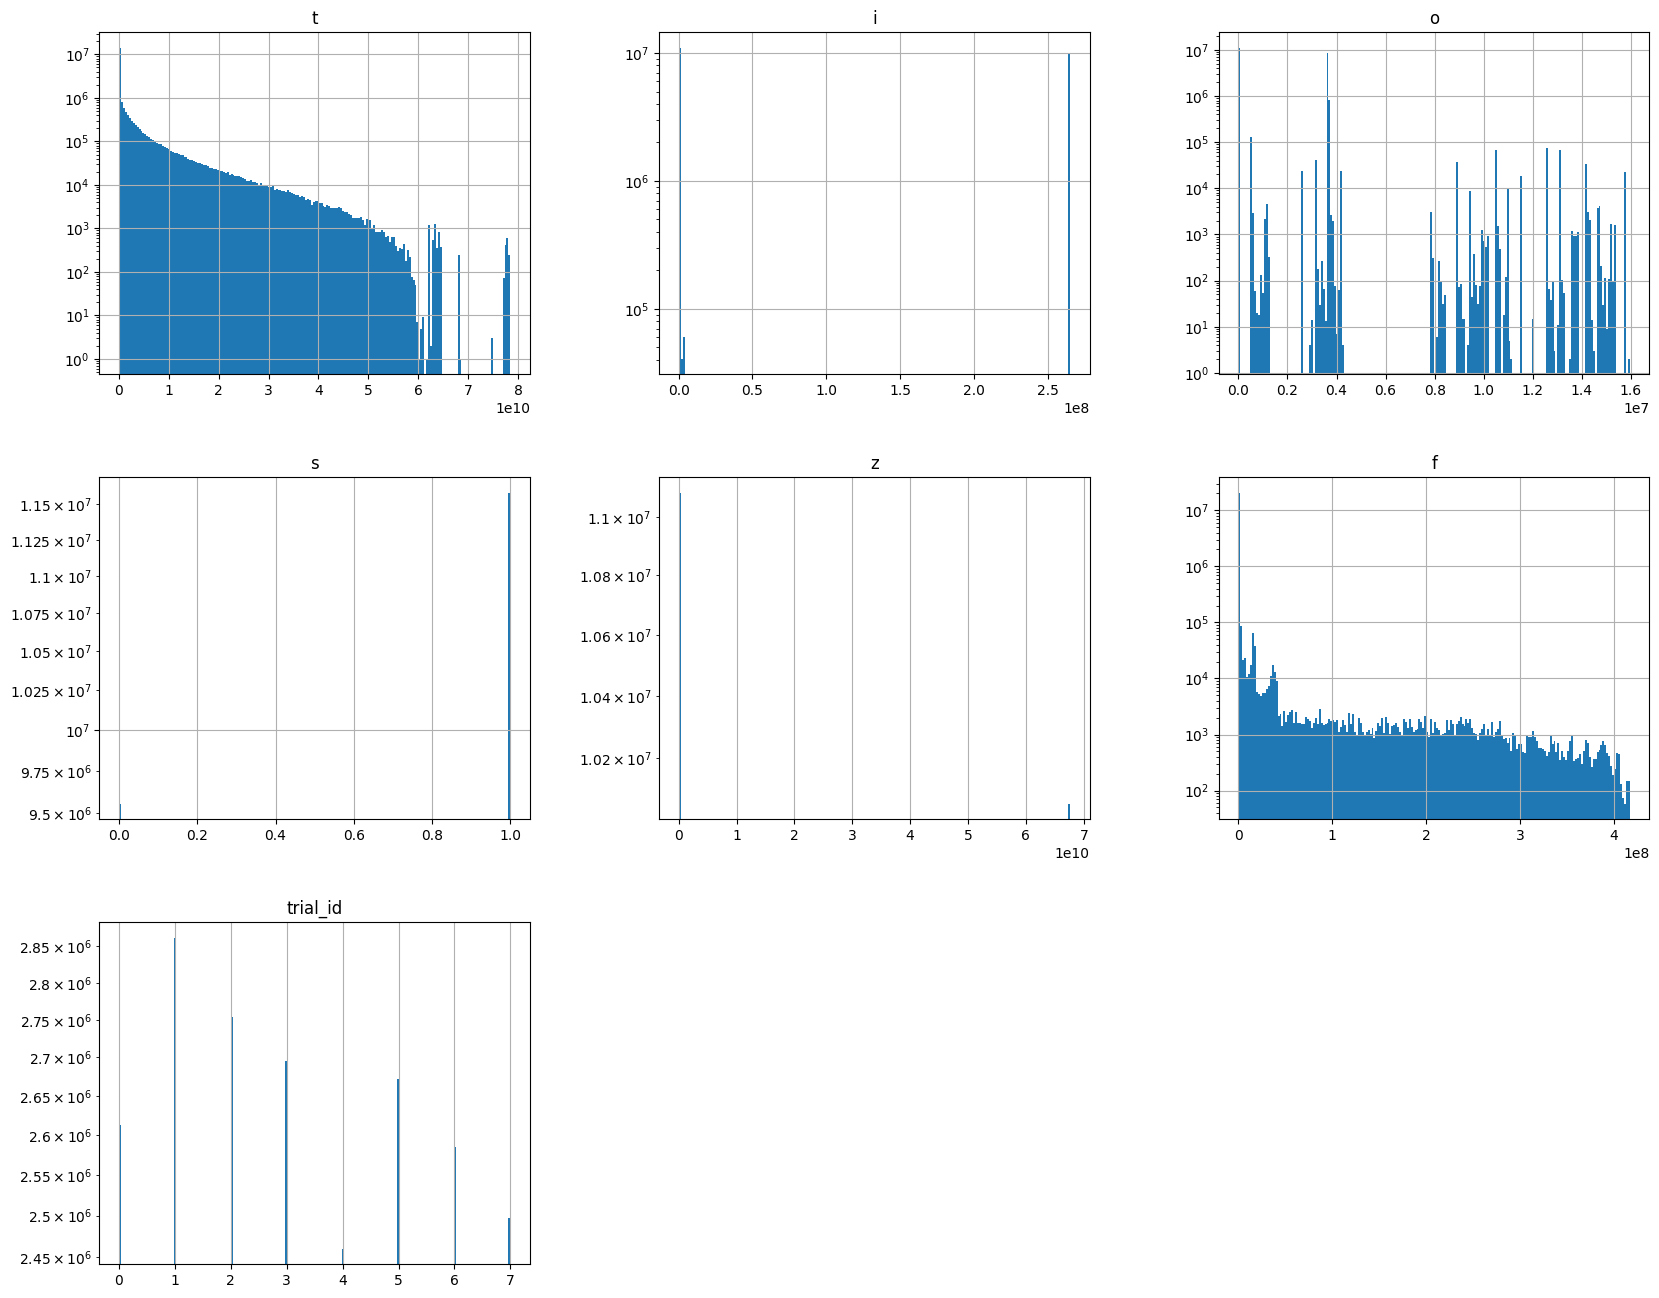

In [16]:
df.hist(figsize=(20,16), bins=200, log=True)
plt.show()

In [5]:
def train_and_transform_discretizer(
    X_train: pd.DataFrame,
    n_bins: int = 5,
    encode: str = 'ordinal',
    strategy: str = 'quantile',
    subsample: int | None = None,
    random_state: int | None = None
) -> tuple[pd.DataFrame, KBinsDiscretizer]:
    """
    Train a KBinsDiscretizer on the training dataset and return the transformed dataframe.
    
    Parameters
    ----------
    X_train : pd.DataFrame
        Training dataset to fit and transform
    n_bins : int, default=5
        Number of bins to produce. Must be >= 2.
    encode : {'onehot', 'onehot-dense', 'ordinal'}, default='ordinal'
        Method used to encode the transformed result.
        - 'onehot': Encode the transformed result with one-hot encoding
        - 'onehot-dense': Same as 'onehot' but returns dense array
        - 'ordinal': Return the bin identifier encoded as an integer value
    strategy : {'uniform', 'quantile', 'kmeans'}, default='quantile'
        Strategy used to define the widths of the bins.
        - 'uniform': All bins have identical widths
        - 'quantile': All bins have the same number of points
        - 'kmeans': Values in each bin have the same nearest center of a 1D k-means cluster
    subsample : int or None, default=None
        Maximum number of samples used to fit the model. If None, all samples are used.
    random_state : int or None, default=None
        Random state for reproducibility when using 'kmeans' strategy.
    
    Returns
    -------
    tuple[pd.DataFrame, KBinsDiscretizer]
        A tuple containing:
        - Transformed dataframe with discretized values
        - Fitted KBinsDiscretizer object for future transformations
    
    Examples
    --------
    >>> import pandas as pd
    >>> X_train = pd.DataFrame({'feature1': [1, 2, 3, 4, 5], 'feature2': [10, 20, 30, 40, 50]})
    >>> X_transformed, discretizer = train_and_transform_discretizer(X_train, n_bins=3)
    >>> print(X_transformed)
    """
    discretizer = KBinsDiscretizer(
        n_bins=n_bins,
        encode=encode,
        strategy=strategy,
        subsample=subsample,
        random_state=random_state
    )

    X_transformed = discretizer.fit_transform(X_train)
    
    X_transformed_df = pd.DataFrame(
        X_transformed,
        columns=X_train.columns,
        index=X_train.index
    )
    
    return X_transformed_df, discretizer


In [6]:
featureset_df, discretizer = train_and_transform_discretizer(df[['t', 'z', 'f']], n_bins=10, strategy='quantile')
featureset_df.head()

/home/jaydenq/projects/learnedcache/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/home/jaydenq/projects/learnedcache/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/jaydenq/projects/learnedcache/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/jaydenq/projects/learnedcache/.

,t,z,f
0,0.0,5.0,0.0
1,0.0,5.0,0.0
2,0.0,5.0,0.0
3,0.0,5.0,0.0
4,0.0,5.0,0.0


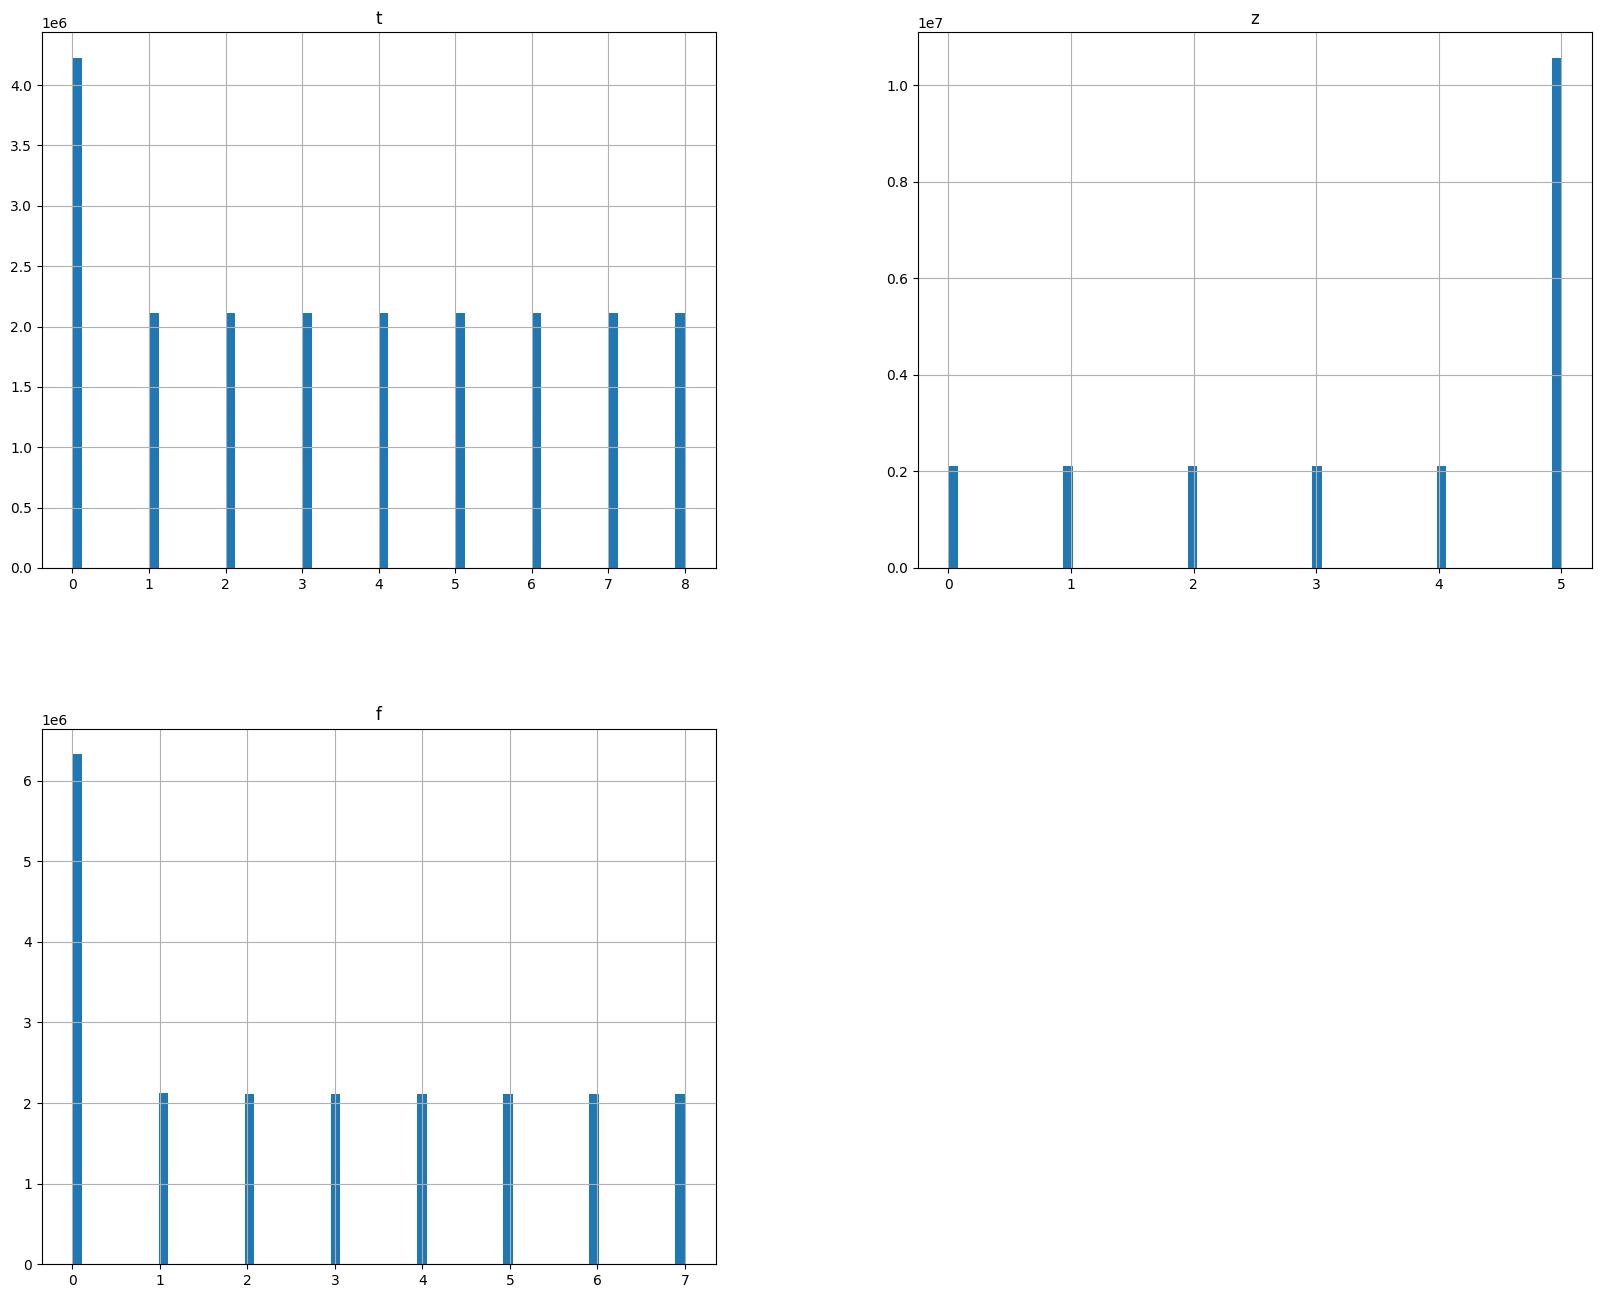

In [7]:
featureset_df.hist(figsize=(20,16), bins = 64)
plt.show()

In [7]:
X = pd.concat([featureset_df, df[['s', 'trial_id']]], axis=1)

In [8]:
Y = df.groupby(['trial_id', 'd', 'i', 'o'])['t'].shift(-1)

print(f"Label Statistics:")
print(f"Total rows: {len(Y)}")
print(f"Labeled rows: {Y.notna().sum()}")
print(f"Unlabeled rows (no future match): {Y.isna().sum()}")
print(f"Label coverage: {Y.notna().sum() / len(Y) * 100:.2f}%")

Label Statistics:
Total rows: 21136516
Labeled rows: 17331622
Unlabeled rows (no future match): 3804894
Label coverage: 82.00%


In [9]:
Y.fillna(1e15, inplace=True)

In [10]:
N_CLASSES = 5
Y_binned, Y_discritizer = train_and_transform_discretizer(Y.to_frame(), n_bins=N_CLASSES, strategy='quantile')

/home/jaydenq/projects/learnedcache/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


array([[<Axes: title={'center': 't'}>]], dtype=object)

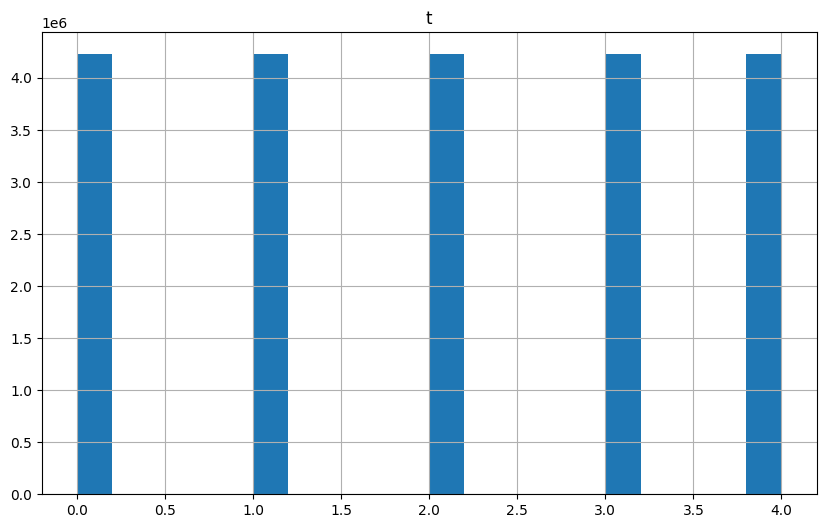

In [11]:
Y_binned.hist(figsize=(10,6), bins=20)

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_binned, test_size=0.2, random_state=42, stratify=Y_binned
)

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
Y_train_np = Y_train.to_numpy().ravel()
Y_test_np = Y_test.to_numpy().ravel()

n_features = X_train_np.shape[1]

print(f"\nData Summary:")
print(f"  Features: {n_features}")
print(f"  Classes: {N_CLASSES}")
print(f"  Training samples: {len(X_train_np)}")
print(f"  Test samples: {len(X_test_np)}")


Data Summary:
  Features: 5
  Classes: 5
  Training samples: 16909212
  Test samples: 4227304


In [ ]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import sys
sys.path.append('..')
from learnedcache.activations import Squaremax, TaylorSoftmax

In [15]:
model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(N_CLASSES),
    Squaremax(),
], name="LearnedCache_squaremax")

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_np, Y_train_np,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Y_pred_prob = model.predict(X_test_np, verbose=0)
Y_pred = np.argmax(Y_pred_prob, axis=1)
accuracy = accuracy_score(Y_test_np, Y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Trained for {len(history.history['loss'])} epochs (early stopping)")
print("\nClassification Report:")
print(classification_report(Y_test_np, Y_pred))

print("\nPer-Class Accuracy:")
for i in range(N_CLASSES):
    mask = Y_test_np == i
    if mask.sum() > 0:
        class_acc = (Y_pred[mask] == i).sum() / mask.sum()
        print(f"  Class {i}: {class_acc:.4f} ({mask.sum()} samples)")

fig = plt.figure(figsize=(16, 5))

ax1 = plt.subplot(1, 3, 1)
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 3, 2)
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

ax3 = plt.subplot(1, 3, 3)
cm = confusion_matrix(Y_test_np, Y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3)
ax3.set_title(f'Confusion Matrix\nAccuracy: {accuracy:.4f}')
ax3.set_ylabel('True Class')
ax3.set_xlabel('Predicted Class')

plt.tight_layout()
plt.show()

Model: "LearnedCache_squaremax"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ squaremax_1 (Squaremax)         │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30 (120.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
 53888/422731 ━━━━━━━━━━━━━━━━━━━━ 3:02 495us/step - accuracy: 0.3706 - loss: 1.4472

KeyboardInterrupt: 

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(N_CLASSES),
    TaylorSoftmax(),
], name="LearnedCache_taylormax")

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_np, Y_train_np,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Y_pred_prob = model.predict(X_test_np, verbose=0)
Y_pred = np.argmax(Y_pred_prob, axis=1)
accuracy = accuracy_score(Y_test_np, Y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Trained for {len(history.history['loss'])} epochs (early stopping)")
print("\nClassification Report:")
print(classification_report(Y_test_np, Y_pred))

print("\nPer-Class Accuracy:")
for i in range(N_CLASSES):
    mask = Y_test_np == i
    if mask.sum() > 0:
        class_acc = (Y_pred[mask] == i).sum() / mask.sum()
        print(f"  Class {i}: {class_acc:.4f} ({mask.sum()} samples)")

fig = plt.figure(figsize=(16, 5))

ax1 = plt.subplot(1, 3, 1)
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 3, 2)
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

ax3 = plt.subplot(1, 3, 3)
cm = confusion_matrix(Y_test_np, Y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3)
ax3.set_title(f'Confusion Matrix\nAccuracy: {accuracy:.4f}')
ax3.set_ylabel('True Class')
ax3.set_xlabel('Predicted Class')

plt.tight_layout()
plt.show()

MODEL 1: REGRESSION PERCEPTRON

Regression Data:
  Features: 5
  Training samples: 16909212
  Test samples: 4227304
  Y range: [0.00e+00, 1.00e+15]

Regression Model Architecture:


2026-01-24 16:12:21.176999: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "Regression_Perceptron"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6 (24.00 B)

 Trainable params: 6 (24.00 B)

 Non-trainable params: 0 (0.00 B)


Training Regression Model...


KeyboardInterrupt: 